In [2]:
# Всё необходимое для выполнения данной лабораторной работы!
import requests
from time import sleep

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Задание 1. Парсинг - 10 баллов

В этом задании Вам предстоит работать с API сайта <a target="_blank" href="hh.ru">hh.ru</a>. Документация доступна по <a target="_blank" href="https://github.com/hhru/api/blob/master/docs/vacancies.md#search">ссылке</a>.

**Задача:**
1. выбрать 5 интересующих вас профессий (не смежных, т.е. Аналатик и Data Engineer не считается корректным)
2. затем получить доступные по данным профессиям вакансии в Москве и выделить их физические координаты
3. нанести полученные координаты на карту местоположения компаний

*Пример запроса для профессии:*

In [15]:
URL = 'https://api.hh.ru/vacancies'

params = {
    'text': "Физик-ядерщик",
    'area': 1,
    'page': 0,
    'per_page': 10
}

data = requests.get(URL, params).json()
data

{'items': [],
 'found': 0,
 'pages': 1,
 'page': 0,
 'per_page': 10,
 'clusters': None,
 'arguments': None,
 'fixes': None,
 'suggests': None,
 'alternate_url': 'https://hh.ru/search/vacancy?area=1&enable_snippets=true&items_on_page=10&text=%D0%A4%D0%B8%D0%B7%D0%B8%D0%BA-%D1%8F%D0%B4%D0%B5%D1%80%D1%89%D0%B8%D0%BA'}

Если Ваш запрос прошел успешно, то вы получите следующие ключи (значения данных ключей вы найдете по ссылке на документацию):

In [16]:
data.keys()

dict_keys(['items', 'found', 'pages', 'page', 'per_page', 'clusters', 'arguments', 'fixes', 'suggests', 'alternate_url'])

Выберете для нас 5 наиболее интересных специальностей и получите по ним имеющиеся вакансии:

In [17]:
URL = 'https://api.hh.ru/vacancies'

params = {
    'text': 'Уборщик',
    'area': 1,
    'page': 0,
    'per_page': 1
}

data = requests.get(URL, params).json()
data

{'items': [{'id': '116445457',
   'premium': False,
   'name': 'Подработка по выходным дням',
   'department': None,
   'has_test': False,
   'response_letter_required': False,
   'area': {'id': '1', 'name': 'Москва', 'url': 'https://api.hh.ru/areas/1'},
   'salary': {'from': None, 'to': 35000, 'currency': 'RUR', 'gross': False},
   'type': {'id': 'open', 'name': 'Открытая'},
   'address': None,
   'response_url': None,
   'sort_point_distance': None,
   'published_at': '2025-01-28T11:46:59+0300',
   'created_at': '2025-01-28T11:46:59+0300',
   'archived': False,
   'apply_alternate_url': 'https://hh.ru/applicant/vacancy_response?vacancyId=116445457',
   'show_logo_in_search': None,
   'insider_interview': None,
   'url': 'https://api.hh.ru/vacancies/116445457?host=hh.ru',
   'alternate_url': 'https://hh.ru/vacancy/116445457',
   'relations': [],
   'employer': {'id': '3028727',
    'name': 'ГКУ Центр занятости населения города Москвы',
    'url': 'https://api.hh.ru/employers/3028727',

In [18]:
class addresses:
    def __init__(self, name, lat, lng):
        self.name = name
        self.lat = lat
        self.lng = lng

    def print_info(self):
        print(f"Name: {self.name}, Lat: {self.lat}, Lng: {self.lng}")



In [19]:
list_of_addresses = []
for _ in range(5):   #data['pages']
    params['page'] = _

    for i in range(data['per_page']):
      response_data = requests.get(URL, params).json()
      try:
        list_of_addresses.append(addresses(name = response_data['items'][i]['employer']['name'],
                                     lat = response_data['items'][i]['address']['lat'],
                                     lng = response_data['items'][i]['address']['lng']))
      except:
        continue
    sleep(2)
for _ in list_of_addresses:
  addresses.print_info(_)

KeyboardInterrupt: 

In [7]:
print(len(list_of_addresses))

4


Посчитайте сколько всего найдено вакансий:

In [8]:
print(data['found'])

2736


Создайте структуру данных, которая будет хранить в себе имя компании и ее координаты (широта и долгота):

Создайте экземпляр этой структуры данных для каждой компании, которая выставила вакансию:

Найдите количество вакансий, у которых заданы координаты (значения данных может быть пустым):

In [9]:
counter = 0
for _ in range(len(list_of_addresses)):
  if list_of_addresses[_].lat == None or list_of_addresses[_].lng == None:
    counter += 1
print(len(list_of_addresses) - counter)

4


Отберите вакансии, которые расположены в пределах МКАД (можно грубо):

Постройте график в координатах "широта-долгота" для отображения вакансий внутри МКАД (не забывайте прописать прозрачность, чтобы увидеть скопления):

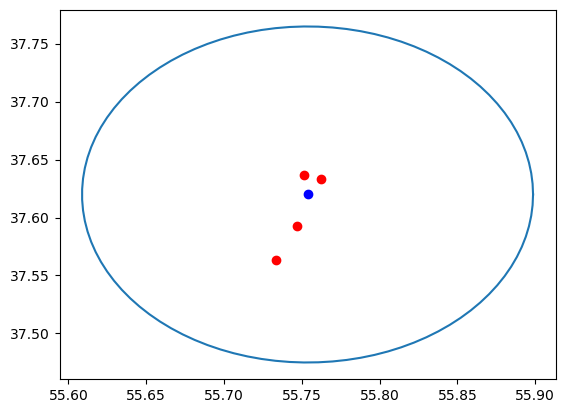

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


center_lat = 55.753674
center_lng = 37.619881
point_lat = 55.894918
point_lng = 37.652472


radius = np.sqrt((point_lat - center_lat)**2 + (point_lng - center_lng)**2)

for _ in range(len(list_of_addresses)):
  if list_of_addresses[_].lat != None and list_of_addresses[_].lng != None:
    if np.sqrt((list_of_addresses[_].lat - center_lat)**2 + (list_of_addresses[_].lng - center_lng)**2) <= radius:
      plt.plot(list_of_addresses[_].lat, list_of_addresses[_].lng, 'ro')


angles = np.linspace(0, 2*np.pi, 100)
circle_lats = center_lat + radius * np.cos(angles)
circle_lngs = center_lng + radius * np.sin(angles)

plt.plot(circle_lats, circle_lngs)

plt.plot(center_lat, center_lng, 'bo', label='Center')

**Сделайте выводы о проделанной работе:**

Вам предстоит проанализировать датасет, содержащий информацию об бриллианта, их стоимости и остальных характеристиках.



Поясним значения хранящиеся в колонках:
*   `cut` - огранка бриллианта (относится к одной из примерно 10 наиболее распространенных)
*   `color` - цвет бриллианта, прозрачные бриллианты имеют градацию `D-Z`, "более высокие" буквы - более желтоватые, но часто имеют лучшие значения, поскольку цвет трудно определить один раз в кольце
*   `clarity` - чистота бриллианта, наличие включений (внутренних дефектов), чем меньше и мельче, тем лучше
*   `carat_weight` - масса бриллианта (слабо связана с размером бриллианта, т.к. огранка и качество огранки, как правило, играют большую роль)
*   `cut_quality` - качество ограники по системе оценки GIA Cut
*   `lab` - лаборатория оценивания
*   `meas_length` - длина бриллианта
*   `meas_width` - ширина бриллианта
*   `meas_depth` - глубина бриллианта
*   `total_sales_price` - цена бриллианта в долларах.
*    **и прочие колонки**

Скачаем данные:

In [14]:
!gdown 10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8
# если работайте в jupyter то скачайте датасет с https://drive.google.com/uc?id=10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8

Downloading...
From: https://drive.google.com/uc?id=10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8
To: c:\Users\gosha\Downloads\diamonds.csv

  0%|          | 0.00/35.4M [00:00<?, ?B/s]
  1%|▏         | 524k/35.4M [00:00<00:15, 2.25MB/s]
  4%|▍         | 1.57M/35.4M [00:00<00:06, 5.30MB/s]
  7%|▋         | 2.62M/35.4M [00:00<00:05, 6.17MB/s]
 10%|█         | 3.67M/35.4M [00:00<00:04, 6.67MB/s]
 13%|█▎        | 4.72M/35.4M [00:00<00:04, 7.14MB/s]
 16%|█▋        | 5.77M/35.4M [00:00<00:04, 7.32MB/s]
 19%|█▉        | 6.82M/35.4M [00:01<00:03, 7.43MB/s]
 22%|██▏       | 7.86M/35.4M [00:01<00:03, 6.95MB/s]
 25%|██▌       | 8.91M/35.4M [00:01<00:03, 7.29MB/s]
 28%|██▊       | 9.96M/35.4M [00:01<00:03, 6.69MB/s]
 31%|███       | 11.0M/35.4M [00:01<00:03, 6.46MB/s]
 34%|███▍      | 12.1M/35.4M [00:01<00:03, 6.43MB/s]
 37%|███▋      | 13.1M/35.4M [00:02<00:03, 6.38MB/s]
 40%|███▉      | 14.2M/35.4M [00:02<00:03, 6.45MB/s]
 43%|████▎     | 15.2M/35.4M [00:02<00:03, 6.40MB/s]
 46%|████▌     | 16.3M/35.4M [00:

Создадим DataFrame:

In [20]:
import pandas as pd

diamonds = pd.read_csv("diamonds.csv")

Выведете первые 5 строк датасета:

In [21]:
diamonds.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


Найдите количество бриллиантов всего в данном датасете:

Выведите максимальную и минимальную цену бриллианта в формате `номер - цена`:

Посчитайте количество пропусков (пропуском считается значение `unknown` или `None`):

Найдите в каких столбцах присутствуют пропуски:

В нашем датасете присутствуют колонки, которые начинаются с `fancy_color_` или `fluor_`. Большинство значений в этих колонках - `unknown` или `None`, поэтому мы считаем их малоинформативными.

Ваша задача:

найти количество таких колонок, которые начинаются с `fancy_color_` или `fluor_`:

найти количество информативных (не `None` или `unknown`) значений в этих колонках:

удалить данные колонки из датасета, сохранив изменения (в дальнейшем работаем измененным датасетом):

Проделайте тоже самое для колонок, начинающихся с `culet_`:

Посчитайте сколько бы стоил (в тысячах долларов) сейф, в котором хранились бы все бриллианты из датасета:

Немного необоснованных манипуляций.

Выберите из датасета строки с четными индексами и выведете значения (не меняя нумерацию индексов):

А теперь с индексами, кратными 6:

Выберете из датасета только категорильные признаки и выведете датасет:

### Построение графиков

**Требования к графику:**

1.   График должен быть подписан
2.   Оси должны быть подписаны
3.   Должна быть легенда графика
4.   График должен быть информативным (желательно без сильных выбросов)

**Все надписи на русском языке!**

>**Примечание**
>
>График необходимо строить для очищенных данных - в них не должно быть пропусков по осям, по которым строите график. При этом **не перезатирайте** имеющийся датафрейм!

Постройте график `цвет бриллианта - стоимость`:

Постройте график `лабараторная оценка - кол-во бриллиантов`:

Постройте график `вес бриллианта - стоимость`:

Постройте график `система оценки GIA Cut - кол-во бриллиантов`:

Сделайте выводы по построенным графикам